# Library Imports and Utilities

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [2]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The Epsilon dataset is a synthetic binary classification benchmark originally introduced for the PASCAL Large Scale Learning Challenge (2008). It was designed to evaluate the performance of machine learning algorithms on high‑dimensional, noisy, and highly nonlinear data, simulating a complex classification task where the decision boundary is intricate and difficult to learn. The dataset was generated using a random non‑linear transformation of a 2,000‑dimensional input space, with a binary target that is derived from a hidden function, making it a challenging testbed for both linear and non‑linear models. It has since become a standard benchmark for assessing scalability and robustness of modern machine learning methods, including kernel methods, gradient‑boosted trees, and deep learning architectures, particularly in large‑scale and high‑dimensional settings.

We used the Epsilon dataset (the first 30 features were selected), which contains 50 000 instances (random sample from the train set) with a 49,9 % anomaly rate. It comprises 30 numerical and 0 categorical features. The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 200 instances for finetuning, of which 100 were anomalies, and the same number (200  instances, 100 anomalies) for testing.

In [4]:
from catboost.datasets import epsilon

train_df, test_df = epsilon()

In [5]:
# Take a random sample from train and keep only the first 30 features
df_raw = train_df.sample(n=50000, random_state=42).iloc[:, :31]

print(f"Size (random sample): {df_raw.shape}")

Size (random sample): (50000, 31)


# Preprocessing

In [6]:
df_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
23218,-1.0,-0.054544,0.005587,-0.019026,0.015695,0.005431,-0.006478,-0.059309,-0.022911,-0.002066,...,-0.034187,-0.009756,-0.008775,0.039567,0.021967,0.003281,0.027386,-0.023702,0.015825,-0.011674
20731,-1.0,-0.021033,0.025888,-0.016522,0.010203,0.034042,-0.025635,0.010573,0.001983,0.031421,...,0.020145,-0.026702,0.029957,0.001559,0.003996,0.017884,-0.020630,-0.010347,-0.036072,0.026610
39555,1.0,0.004586,0.011629,0.034291,-0.003272,-0.009947,0.020118,0.003384,0.006325,-0.024518,...,-0.010435,0.029034,-0.022657,-0.001664,0.014244,0.012603,0.014007,0.036073,0.016521,0.005995
147506,-1.0,0.008058,-0.009157,0.016815,0.029049,-0.007064,0.012944,-0.015676,-0.037662,-0.015312,...,0.015936,0.007180,-0.023325,-0.026356,0.003698,-0.026780,0.031110,0.003405,0.026021,0.027842
314215,1.0,0.034941,0.005374,-0.022401,-0.003352,0.046027,-0.015736,0.002708,0.005228,0.028814,...,0.000311,0.001034,0.020273,0.028636,-0.012753,0.009476,-0.012076,0.025963,-0.027936,0.007933


In [7]:
X = preprocess_dataset(df_raw.drop(columns=[df_raw.columns[0]]))
y = replace_target((df_raw[df_raw.columns[0]] == 1).astype(int).loc[X.index].squeeze())
y = replace_target(y)

No constant features were found
Size after preprocessing: (50000, 30)


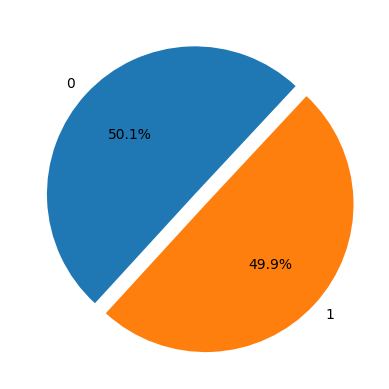

In [8]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [9]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 25071
Класс 1 : 24929


In [10]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
8,9,"[-0.00206564, 0.0314212, -0.0245184, -0.015312...",48172,float32
22,23,"[-0.00877459, 0.0299571, -0.0226565, -0.023324...",48388,float32
12,13,"[0.00019577, 0.0222877, -0.0388216, -0.0410333...",48439,float32
14,15,"[-0.0177292, 0.0318178, -0.01913, -0.00955522,...",48490,float32
13,14,"[0.020691, -0.0397549, 0.00120163, 0.0187247, ...",48493,float32
17,18,"[0.0195667, 0.0336447, -0.011884, -0.0287201, ...",48577,float32
4,5,"[0.0054309, 0.0340416, -0.00994725, -0.0070640...",48590,float32
21,22,"[-0.00975621, -0.0267016, 0.029034, 0.00717994...",48619,float32
10,11,"[-0.024914, 8.69937e-05, 0.0336034, -0.0001037...",48637,float32
5,6,"[-0.00647753, -0.0256355, 0.0201182, 0.0129444...",48691,float32


In [11]:
num_cols = X.columns.tolist()
cat_cols = []